# 1. Set up the notebook

Do imports.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from IPython.display import Image
from ae483.tools import *
from ae483.mytools import *

# 2. Estimate the mass

Find the mass $m$ of the drone in kilograms.

In [2]:
#in kg
m = .034 # <-- fixed? 

Find a worst-case bound $\Delta m$ on the uncertainty of your estimate. This bound should be chosen so that the true mass is guaranteed to be in the interval $[m - \Delta m, m + \Delta m]$.

In [3]:
#+/- 1g uncertainty from scale specs
delta_m = 0.001 # <-- fixed? 

# 3. Estimate the moment of inertia about the $x_B$-axis

Show a picture of your rig (change the file name or file extension as appropriate).

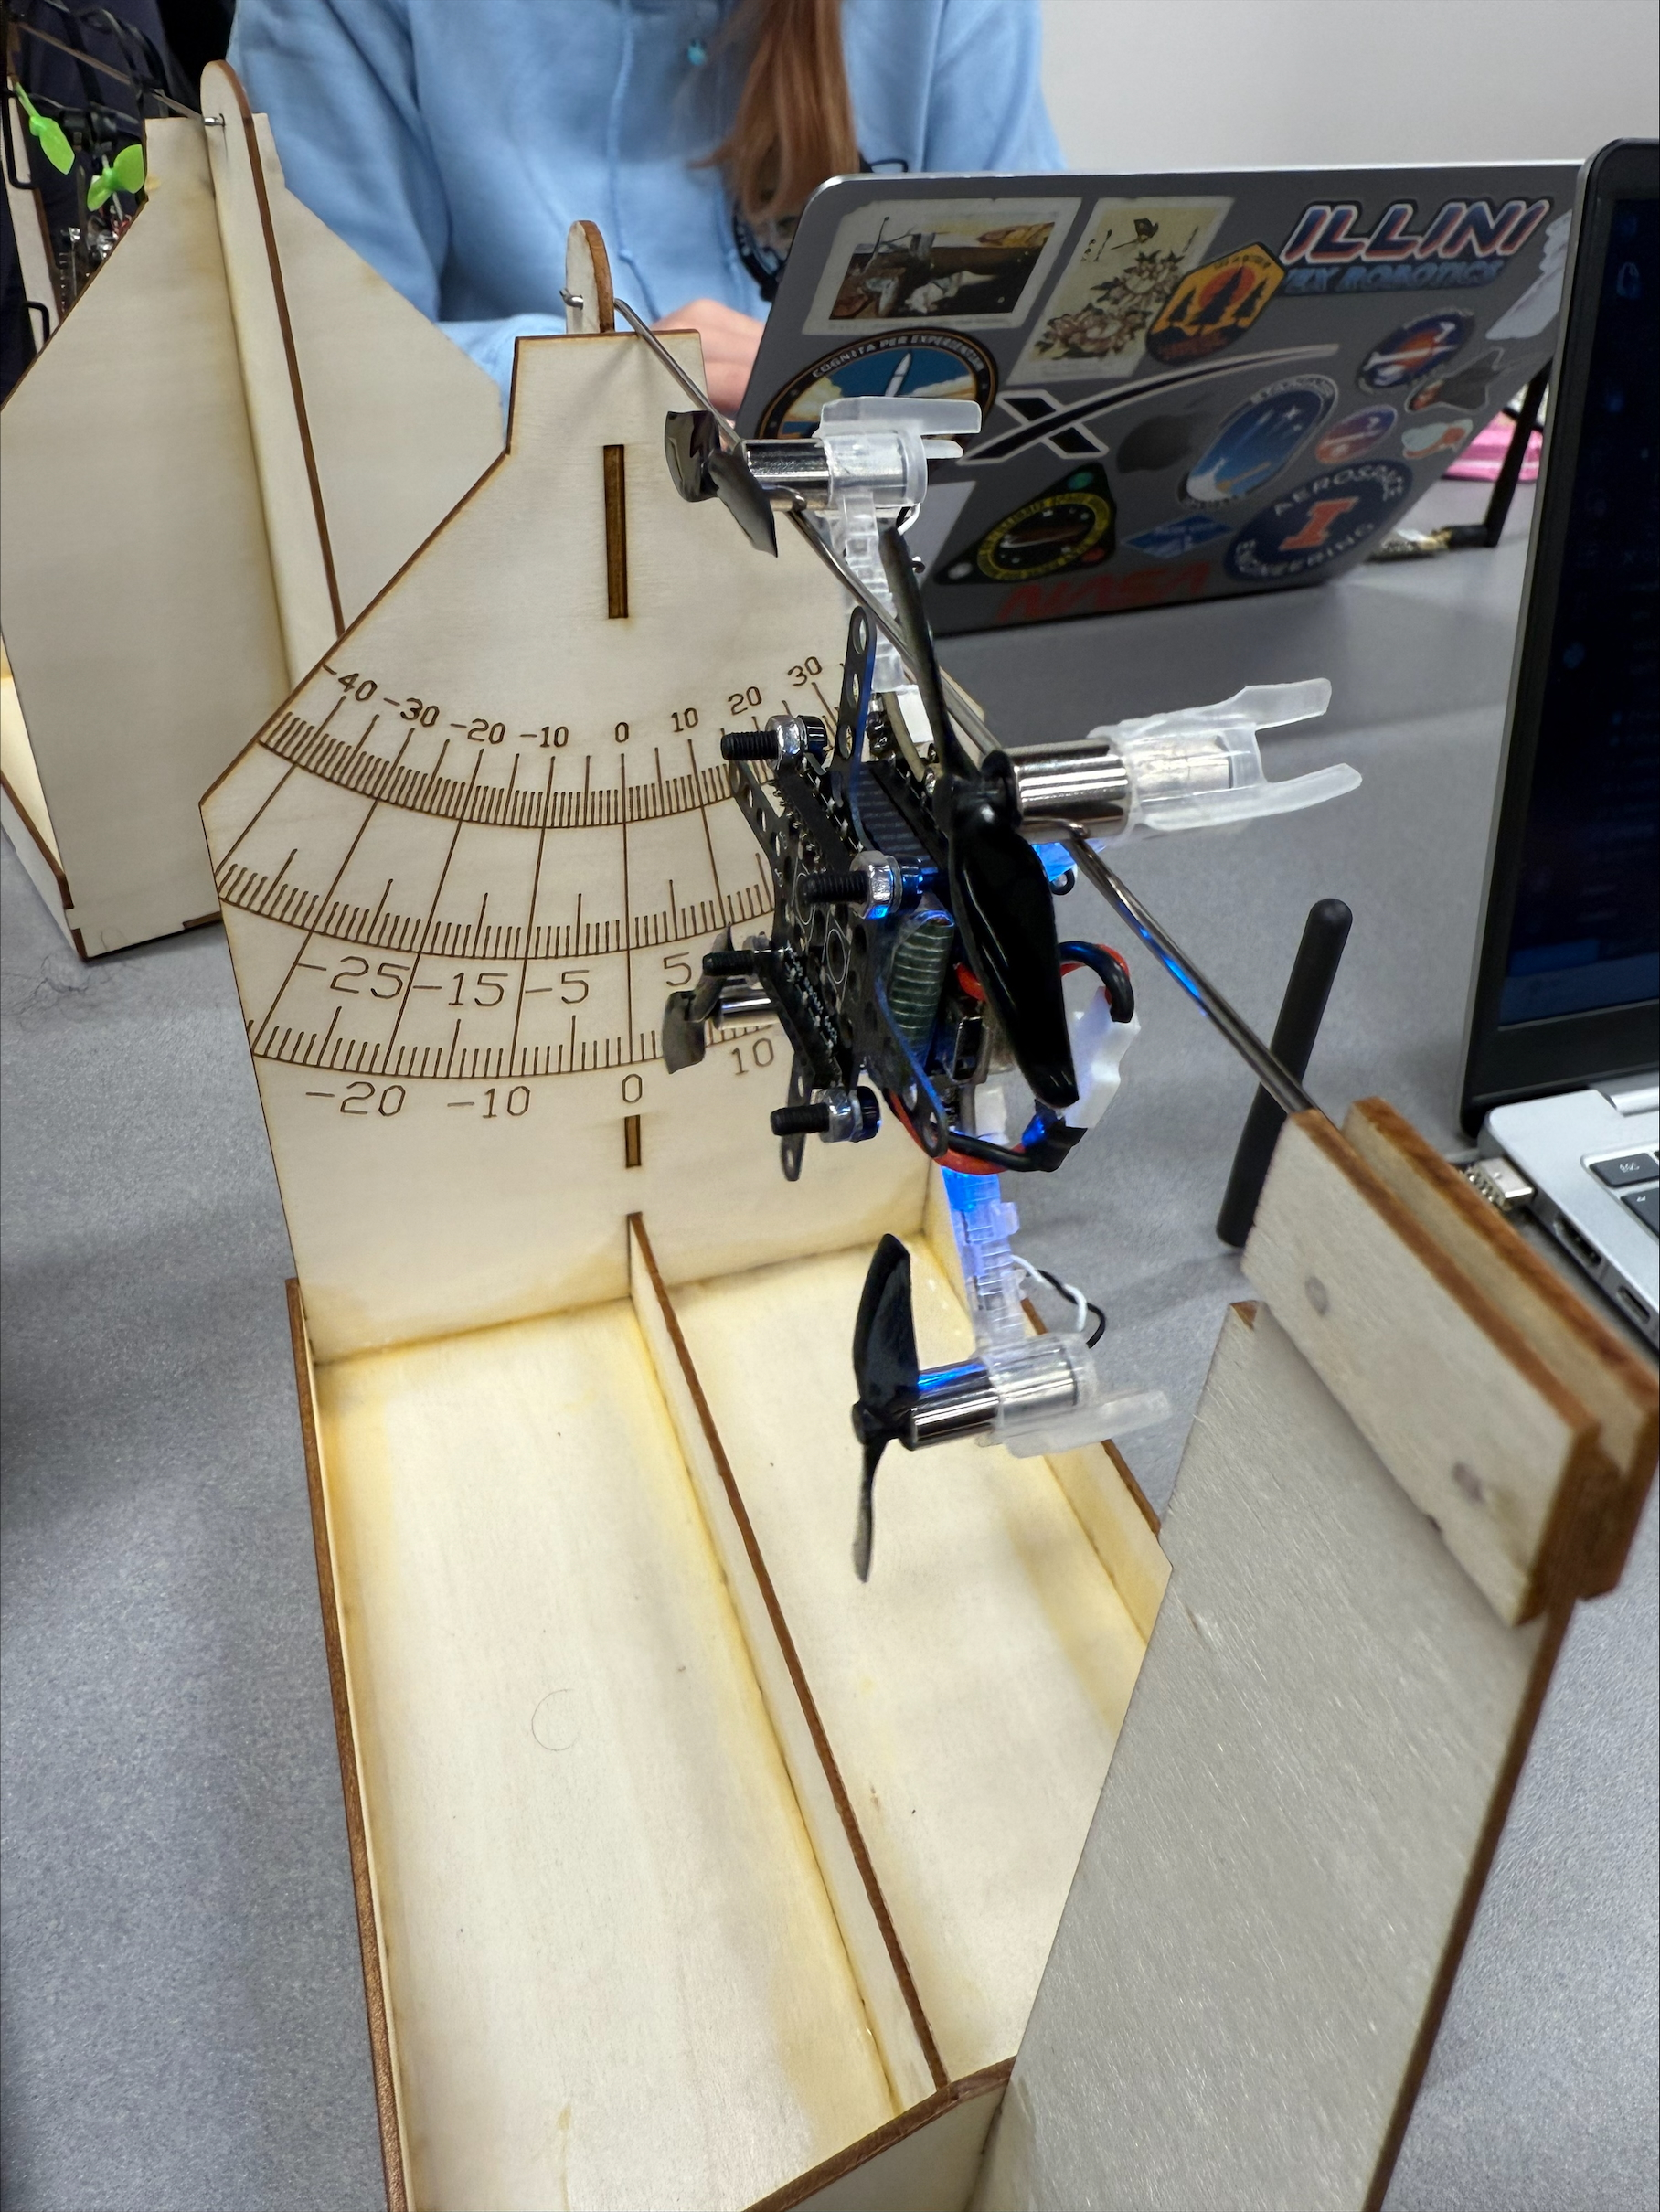

In [4]:
Image(filename='x-rig.png', width=480)

Find the distance in meters between the axis of rotation and the center of mass.

In [6]:
#in m
r = .032 # <-- fixed?

Find a worst-case bound $\Delta r$ on the uncertainty of your estimate.

In [5]:
#in m (from a ruler 1mm)
delta_r = 0.001 # <-- fixed?

Load, resample, and parse data to get time and the three components of angular velocity (in radians / second).

Remember that `resample_drone_data` has two optional arguments that allow you to discard data at the start and end of the experiment. You may find these arguments useful, since you will likely find that some of the data at the start and end of your experiment are garbage.

In [7]:
# Load data
raw_data_drone, raw_data_mocap, raw_data_bodies = load_hardware_data('x_data.json')

# Resample data
data_drone = resample_data_drone(
    raw_data_drone,
    t_min_offset=2.,    # <-- fixed?
    t_max_offset=0.,    # <-- FIXME
)

# Parse data
t = data_drone['time']
w_x = np.deg2rad(data_drone['gyro.x'])
w_y = np.deg2rad(data_drone['gyro.y'])
w_z = np.deg2rad(data_drone['gyro.z'])

Plot all three components of angular velocity. You are trying to estimate the moment of inertia about the $x$ axis. The component of angular velocity about this axis should be large, and the components of angular velocity about the other two axes should be negligibly small. It is important to check this. (Please also check if you have data at the start and end of the experiment that need to be discarded.)

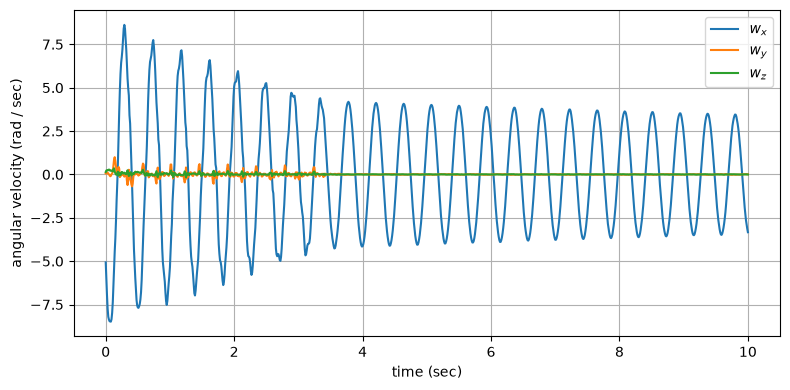

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), tight_layout=True)
ax.plot(t, w_x, label='$w_x$')
ax.plot(t, w_y, label='$w_y$')
ax.plot(t, w_z, label='$w_z$')
ax.set_xlabel('time (sec)')
ax.set_ylabel('angular velocity (rad / sec)')
ax.legend()
ax.grid()
plt.show()

You should find that `w_x` is oscillatory. The period is the peak-to-peak time. You could measure the period by hand, but it is easier to automate this process, particularly if you want to average your estimate of the period over many oscillations.

Here is one way to do it:

* Find the index $i_k$ of each peak $k\in\{0, \dotsc, n-1\}$ in your data.
* Find the time $t_k$ at each peak for $k\in\{0, \dotsc, n-1\}$.
* Find the difference $T_k = t_{k+1} - t_k$ between consecutive peak times for $k \in \{0, \dotsc, n-2\}$.
* Find the mean difference: $$\widehat{T} = \dfrac{1}{n-1} \sum_{k=0}^{n-2} T_k.$$ This is an estimate of the oscillation period.

Here is one way to implement this in code, using [scipy.signal.find_peaks](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html):

In [9]:
# Find the index of each peak (increase "prominence" if you get bad results)
peaks = find_peaks(w_x, prominence=0.3)
i_peaks = peaks[0]

# Find the time at each peak
t_peaks = t[i_peaks]

# Find w_x at each peak (for visualization)
w_x_peaks = w_x[i_peaks]

# Find the difference between consecutive peak times
#
# Note:
#
#  t_peaks[1:] means t_peaks without the first element
#  t_peaks[:-1] means t_peaks without the last element
#
# So, t_peaks[1:] - t_peaks[:-1] produces the following array:
#
#  [t_peaks[1]-t_peaks[0], t_peaks[0]-t_peaks[1], ...]
#
t_diff = t_peaks[1:] - t_peaks[:-1]

# Find the mean difference as an estimate of the oscillation period
T = np.mean(t_diff)

# Print the estimate
print(f'T = {T:.4f} sec')

T = 0.4323 sec


Sanity check — plot the peaks. (the peaks are marked based on time and this is relatively correct to where the peaks are)

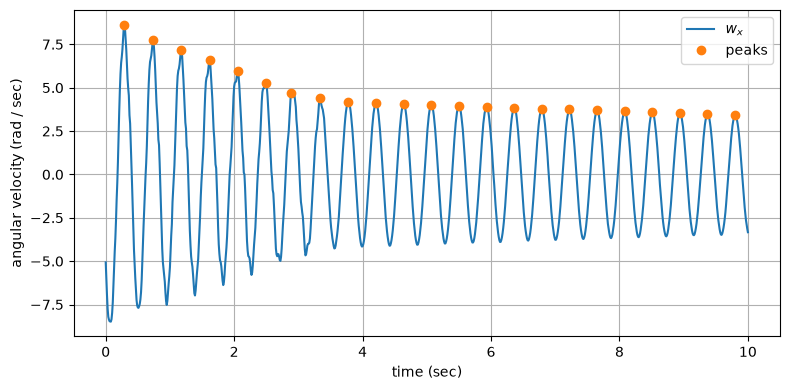

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), tight_layout=True)
ax.plot(t, w_x, label='$w_x$')
ax.plot(t_peaks, w_x_peaks, '.', markersize=12, label='peaks')
ax.set_xlabel('time (sec)')
ax.set_ylabel('angular velocity (rad / sec)')
ax.legend()
ax.grid()
plt.show()

Sanity check — plot the differences between consecutive peak times. (**FIXME: How do you know these results are good?**)

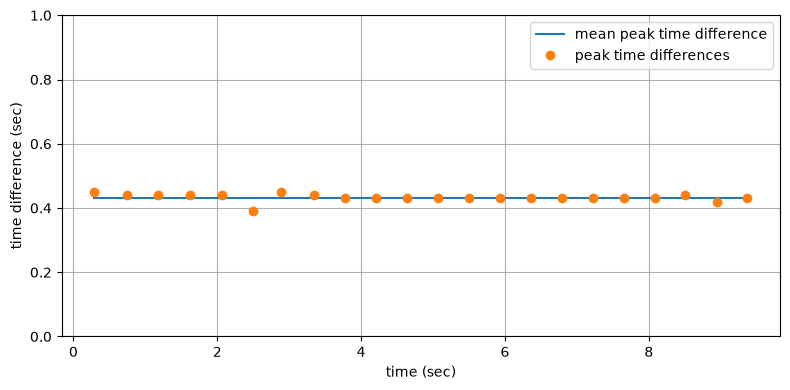

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), tight_layout=True)
ax.plot(t_peaks[:-1], T * np.ones_like(t_peaks[:-1]), label='mean peak time difference')
ax.plot(t_peaks[:-1], t_diff, '.', markersize=12, label='peak time differences')
ax.set_ylim(0., 1.)
ax.set_xlabel('time (sec)')
ax.set_ylabel('time difference (sec)')
ax.grid()
ax.legend()
plt.show()

Find a worst-case bound $\Delta T$ on the uncertainty of your estimate.

In [12]:
#finding mean minus the minimum to get the greatest uncertainty in the period
min_T=np.min(t_diff)
mean_T=np.mean(t_diff)
delta_T = mean_T - min_T # <-- fixed?

delta_T

np.float64(0.04227272727272713)

Find the moment of inertia about the $x$ axis.

In [18]:
from sympy import *
import numpy as np

J_x = symbols('J_x', positive=True, real=True)
eqn = Eq(((2*np.pi)/T)**2, (m*9.81*r)/J_x+m*r**2)

soln = solve(eqn, J_x)

J_x = soln[0] # <-- FIXME
J_x

5.05189028125759e-5

Find a worst-case bound $\Delta J_x$ on the uncertainty in your estimate.

In [27]:
import math

g_val = 9.81              

dJ_dT = (m * g_val * r * T) / (2 * math.pi**2)

dJ_dm = ((g_val * r * T**2) / (4 * math.pi**2) - r**2)

dJ_dr = ((m * g_val * T**2) / (4 * math.pi**2) - 2 * m * r)

delta_J_x = abs(dJ_dT*delta_T) + abs(dJ_dm*delta_m) + abs(dJ_dr*delta_r)

print('Worst case bound =', delta_J_x)
print('Moment of inertia =', J_x)

Worst case bound = 1.0939801445778003e-05
Moment of inertia = 5.05189028125759e-5


# 4. Estimate the moment of inertia about the $y_B$-axis

Add cells here to repeat the same process as above...

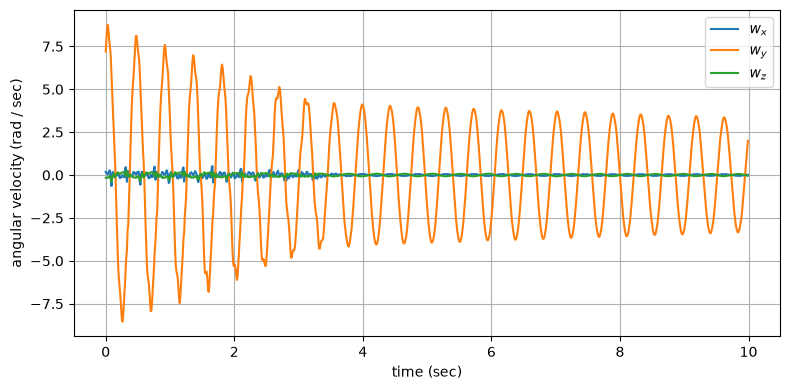

T_y = 0.4359 sec


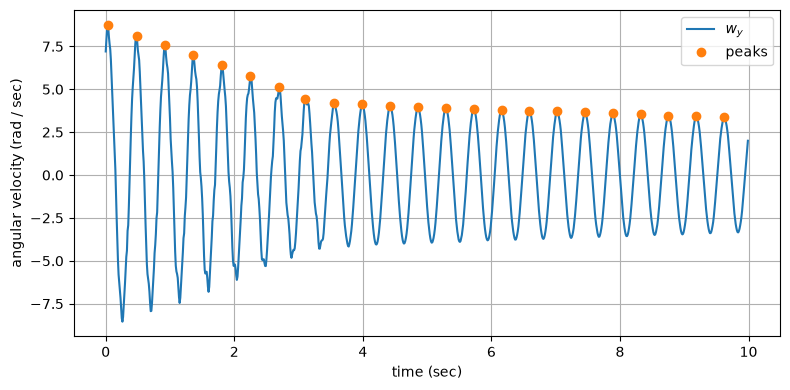

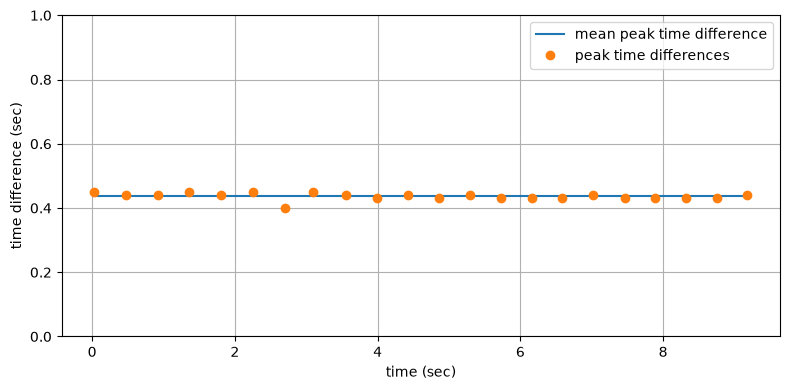

delta_T_y = 0.0359 sec
J_y = 0.0000513724279240394 kg*m^2


In [31]:
r_y = .032 #m
delta_r_y = 0.001 #m

# Load data
raw_data_drone, raw_data_mocap, raw_data_bodies = load_hardware_data('y_data.json')

# Resample data
data_drone = resample_data_drone(
    raw_data_drone,
    t_min_offset=2.,    # <-- fixed?
    t_max_offset=0.,    # <-- FIXME
)

# Parse data
t = data_drone['time']
w_x = np.deg2rad(data_drone['gyro.x'])
w_y = np.deg2rad(data_drone['gyro.y'])
w_z = np.deg2rad(data_drone['gyro.z'])

#gyro plot
fig, ax = plt.subplots(1, 1, figsize=(8, 4), tight_layout=True)
ax.plot(t, w_x, label='$w_x$')
ax.plot(t, w_y, label='$w_y$')
ax.plot(t, w_z, label='$w_z$')
ax.set_xlabel('time (sec)')
ax.set_ylabel('angular velocity (rad / sec)')
ax.legend()
ax.grid()
plt.show()

# Find the index of each peak (increase "prominence" if you get bad results)
peaks = find_peaks(w_y, prominence=0.3)
i_peaks = peaks[0]

# Find the time at each peak
t_peaks = t[i_peaks]

# Find w_x at each peak (for visualization)
w_y_peaks = w_y[i_peaks]

# Find the difference between consecutive peak times
#
# Note:
#
#  t_peaks[1:] means t_peaks without the first element
#  t_peaks[:-1] means t_peaks without the last element
#
# So, t_peaks[1:] - t_peaks[:-1] produces the following array:
#
#  [t_peaks[1]-t_peaks[0], t_peaks[0]-t_peaks[1], ...]
#
t_diff = t_peaks[1:] - t_peaks[:-1]

# Find the mean difference as an estimate of the oscillation period
T_y = np.mean(t_diff)

# Print the estimate
print(f'T_y = {T_y:.4f} sec')

#plot with peaks
fig, ax = plt.subplots(1, 1, figsize=(8, 4), tight_layout=True)
ax.plot(t, w_y, label='$w_y$')
ax.plot(t_peaks, w_y_peaks, '.', markersize=12, label='peaks')
ax.set_xlabel('time (sec)')
ax.set_ylabel('angular velocity (rad / sec)')
ax.legend()
ax.grid()
plt.show()

#peaks sanity check
fig, ax = plt.subplots(1, 1, figsize=(8, 4), tight_layout=True)
ax.plot(t_peaks[:-1], T * np.ones_like(t_peaks[:-1]), label='mean peak time difference')
ax.plot(t_peaks[:-1], t_diff, '.', markersize=12, label='peak time differences')
ax.set_ylim(0., 1.)
ax.set_xlabel('time (sec)')
ax.set_ylabel('time difference (sec)')
ax.grid()
ax.legend()
plt.show()

#finding mean minus the minimum to get the greatest uncertainty in the period
min_T=np.min(t_diff)
mean_T=np.mean(t_diff)
delta_T_y = mean_T - min_T # <-- fixed?

print(f'delta_T_y = {delta_T_y:.4f} sec')

J_y = symbols('J_y', positive=True, real=True)
eqn = Eq(((2*np.pi)/T_y)**2, (m*9.81*r_y)/J_y+m*r_y**2)

soln = solve(eqn, J_y)

J_y = soln[0] 
print(f'J_y = {J_y} kg*m^2')


Find a worst-case bound $\Delta J_y$ on the uncertainty in your estimate.

In [32]:
g_val = 9.81              

dJ_dT = (m * g_val * r_y * T_y) / (2 * math.pi**2)

dJ_dm = ((g_val * r_y * T_y**2) / (4 * math.pi**2) - r_y**2)

dJ_dr = ((m * g_val * T_y**2) / (4 * math.pi**2) - 2 * m * r_y)

delta_J_y = abs(dJ_dT*delta_T_y) + abs(dJ_dm*delta_m) + abs(dJ_dr*delta_r_y)

print('Worst case bound =', delta_J_y)
print('Moment of inertia =', J_y)

Worst case bound = 9.521425939364575e-06
Moment of inertia = 5.13724279240394e-5


# 5. Estimate the moment of inertia about the $z_B$-axis

Add cells here to repeat the same process as above...

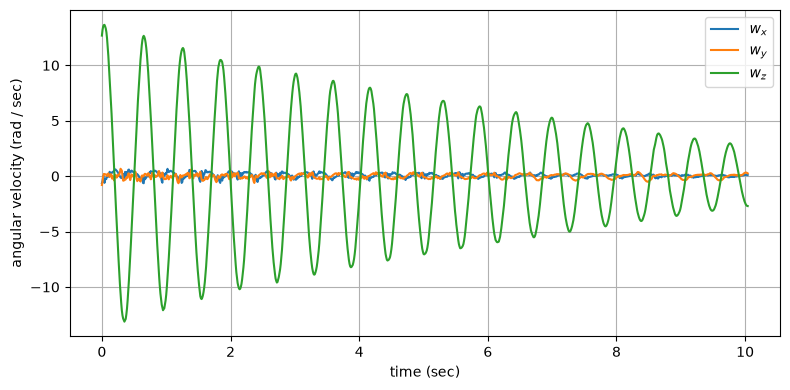

T_z = 0.5718 sec


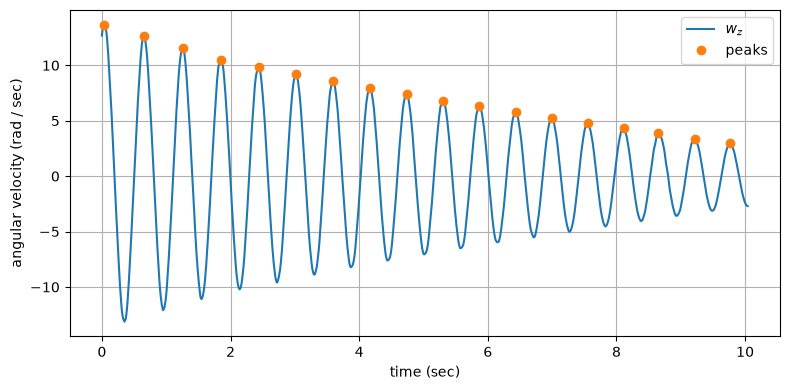

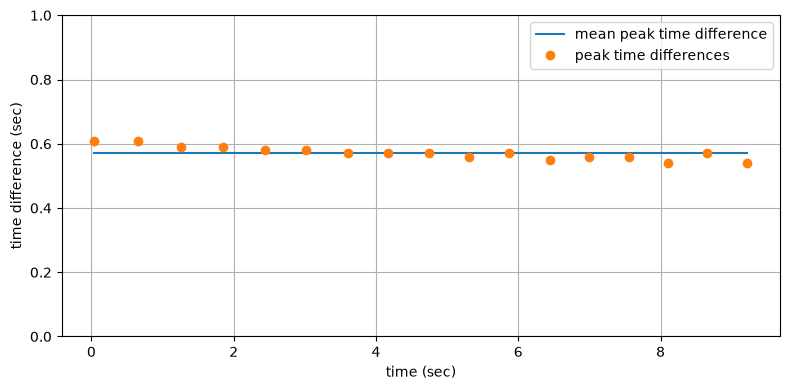

delta_T_z = 0.0318 sec
J_z = 0.0000441919218375210 kg*m^2


In [39]:
r_z = .016 #m
delta_r_z = 0.001 #m

# Load data
raw_data_drone, raw_data_mocap, raw_data_bodies = load_hardware_data('z_data.json')

# Resample data
data_drone = resample_data_drone(
    raw_data_drone,
    t_min_offset=2.,    # <-- fixed?
    t_max_offset=0.,    # <-- FIXME
)

# Parse data
t = data_drone['time']
w_x = np.deg2rad(data_drone['gyro.x'])
w_y = np.deg2rad(data_drone['gyro.y'])
w_z = np.deg2rad(data_drone['gyro.z'])

#gyro plot
fig, ax = plt.subplots(1, 1, figsize=(8, 4), tight_layout=True)
ax.plot(t, w_x, label='$w_x$')
ax.plot(t, w_y, label='$w_y$')
ax.plot(t, w_z, label='$w_z$')
ax.set_xlabel('time (sec)')
ax.set_ylabel('angular velocity (rad / sec)')
ax.legend()
ax.grid()
plt.show()

# Find the index of each peak (increase "prominence" if you get bad results)
peaks = find_peaks(w_z, prominence=.3)
i_peaks = peaks[0]

# Find the time at each peak
t_peaks = t[i_peaks]

# Find w_x at each peak (for visualization)
w_z_peaks = w_z[i_peaks]

# Find the difference between consecutive peak times
#
# Note:
#
#  t_peaks[1:] means t_peaks without the first element
#  t_peaks[:-1] means t_peaks without the last element
#
# So, t_peaks[1:] - t_peaks[:-1] produces the following array:
#
#  [t_peaks[1]-t_peaks[0], t_peaks[0]-t_peaks[1], ...]
#
t_diff = t_peaks[1:] - t_peaks[:-1]

# Find the mean difference as an estimate of the oscillation period
T_z = np.mean(t_diff)

# Print the estimate
print(f'T_z = {T_z:.4f} sec')

#plot with peaks
fig, ax = plt.subplots(1, 1, figsize=(8, 4), tight_layout=True)
ax.plot(t, w_z, label='$w_z$')
ax.plot(t_peaks, w_z_peaks, '.', markersize=12, label='peaks')
ax.set_xlabel('time (sec)')
ax.set_ylabel('angular velocity (rad / sec)')
ax.legend()
ax.grid()
plt.show()

#peaks sanity check
fig, ax = plt.subplots(1, 1, figsize=(8, 4), tight_layout=True)
ax.plot(t_peaks[:-1], T_z * np.ones_like(t_peaks[:-1]), label='mean peak time difference')
ax.plot(t_peaks[:-1], t_diff, '.', markersize=12, label='peak time differences')
ax.set_ylim(0., 1.)
ax.set_xlabel('time (sec)')
ax.set_ylabel('time difference (sec)')
ax.grid()
ax.legend()
plt.show()

#finding mean minus the minimum to get the greatest uncertainty in the period
min_T=np.min(t_diff)
mean_T=np.mean(t_diff)
delta_T_z = mean_T - min_T # <-- fixed?

print(f'delta_T_z = {delta_T_z:.4f} sec')

J_z = symbols('J_z', positive=True, real=True)
eqn = Eq(((2*np.pi)/T_z)**2, (m*9.81*r_z)/J_z+m*r_z**2)

soln = solve(eqn, J_z)

J_z = soln[0] 
print(f'J_z = {J_z} kg*m^2')


Find a worst-case bound $\Delta J_z$ on the uncertainty in your estimate.

In [40]:
g_val = 9.81              

dJ_dT = (m * g_val * r_z * T_z) / (2 * math.pi**2)

dJ_dm = ((g_val * r_z * T_z**2) / (4 * math.pi**2) - r_z**2)

dJ_dr = ((m * g_val * T_z**2) / (4 * math.pi**2) - 2 * m * r_z)

delta_J_z = abs(dJ_dT*delta_T_z) + abs(dJ_dm*delta_m) + abs(dJ_dr*delta_r_z)

print('Worst case bound =', delta_J_z)
print('Moment of inertia =', J_z)

Worst case bound = 7.627970412664943e-06
Moment of inertia = 4.41919218375210e-5


# 6. Summarize and discuss the results

### Summary of results

In [41]:
print(f'm = {m:.4f} +/- {delta_m:.4f} kg')
print(f'J_x = {J_x:.2e} +/- {delta_J_x:.2e} kg m^2')
print(f'J_y = {J_y:.2e} +/- {delta_J_y:.2e} kg m^2')
print(f'J_z = {J_z:.2e} +/- {delta_J_z:.2e} kg m^2')

m = 0.0340 +/- 0.0010 kg
J_x = 5.05e-5 +/- 1.09e-05 kg m^2
J_y = 5.14e-5 +/- 9.52e-06 kg m^2
J_z = 4.42e-5 +/- 7.63e-06 kg m^2


### Analysis of uncertainty

**Modify the text in this cell** to answer the following questions:
* Which computed quantities ($J_x$, $J_y$, $J_z$) are the most uncertain?
* Which measured quantities ($m$, $r$, $T$) contribute the most to uncertainty in the computed quantities?
* What assumptions were made and to what extent were these assumptions violated?
* What sources of error might not be captured in your analysis of uncertainty?

$J_x$ is the most uncertain  

$T$ contributes the most to uncertainty in our quantities  

$r$ assumed that the center of the drone was the drone's center of mass. This was likely violated a bit since the drone has different wires and plugs on its front and rear end, and the battery may not be perfectly centered. We take the average of the oscillation period, but the average may not be the most accurate representation of all the osccilations.   

The drone's sensors may not be accurate and can read the oscillations improperly, we can't know how accurate it actually is. We are also assuming no friction between the drone and the pole it swung on.

### Ways to improve the results

**Modify the text in this cell** to propose at least one way in which the experiments or the analysis could be improved to get estimates of mass and moments of inertia that are more accurate (i.e., less uncertain). You could suggest improvements to your current method of approach, but you are also welcome to suggest a completely different method of approach.

We're assuming a fixed axis, but the pole shifts as the drone swings. One thing we can do is have the pole that the drone swings on be more fixed and stable, and try to ensure that the drone does not shift on it as it swings. We can also take friction into account.

### Reflection

Review the reflection you put in your Lab 2 notebook. **Modify the text in this cell** to answer the following three questions with at least one sentence each:
* What was your biggest struggle this week? Was it the same or different from last week?
* What was the most important thing you learned this week?
* How does what you learned this week relate to what you learned last week?

This week we struggled with getting our math to be correct. We had confusion on whether to use $T$ or $\Delta_T$ in our equations, and we had math errors that caused our uncertainty to be bigger than our value at times.

You should check your work. Make sure that what you're doing in your code matches what you wrote on paper.  

In both cases we struggled to take what we know and put it into code.